I'm trying to come up with a collection of sets of compounds from lead-optimization papers in ChEMBL. 

In [1]:
import numpy
from rdkit.Chem.Draw import IPythonConsole
import pandas as pd
from rdkit import Chem
from rdkit.Chem import Draw
import pickle
from rdkit import rdBase
print(rdBase.rdkitVersion)
%load_ext sql
%config SqlMagic.feedback = False
%config SqlMagic.named_parameters="enabled"

from matplotlib import pyplot as plt
%matplotlib inline

import time
print(time.asctime())

2026.03.3
Wed Jul  1 17:28:48 2026


A preliminary query to see how many Ki and IC50 assays there are from patents or publications with a DOI (to make finding the document easier later) that have data for between 30 and 100 compounds. This is the type of query I've used before (with varying threshold values) when trying to find lead optimization sets.

In [2]:
d = %sql postgresql://lebanon/chembl_37 \
select * from (\
   select assay_id,assays.chembl_id assay_chembl_id,count(distinct(molregno)) cnt,description  \
          from activities join docs using (doc_id) join assays using(assay_id) \
          where standard_type = 'Ki' or standard_type='IC50' and confidence_score=9 and assay_type='B' and relationship_type='D' \
          and pchembl_value is not null and ((doc_type='PATENT') or (doc_type='PUBLICATION' and doi is not null))\
          group by (assay_id,assays.chembl_id,description) order by cnt desc) tmp \
   where cnt<100 and cnt>30;
print(f'{len(d)} assays found')

8597 assays found


To make the rest of the work more efficient, I'm going to create a bunch of extra tables in my local copy of the ChEMBL database. I'll collect those in a schema called `lead_opt`:

In [5]:
%sql \
    create schema if not exists lead_opt;

++
||
++
++

Now create some utility tables:
- `doc_assay_count`: the number of assays in each patent and publication document
- `doc_adme_assay_count`: the number of assays of type `A` (ADME) in each patent and publication document
- `doc_binding_assay_count`: the number of assays of type `B` (binding) in each patent and publication document
- `doc_tox_assay_count`: the number of assays of type `T` (toxicity) in each patent and publication document
- `compound_doc_count`: the number of different documents each compound appears in


In [ ]:
%sql \
drop table if exists lead_opt.doc_assay_count;
%sql \
select doc_id,docs.chembl_id,count(distinct(assay_id)) assay_count into lead_opt.doc_assay_count \
  from activities join docs using (doc_id) \
where ((doc_type='PATENT') or (doc_type='PUBLICATION' and doi is not null)) \
 group by (doc_id,docs.chembl_id);

%sql \
drop table if exists lead_opt.doc_adme_assay_count;
%sql \
select docs.doc_id,docs.chembl_id,count(distinct(assay_id)) assay_count into lead_opt.doc_adme_assay_count \
  from activities join docs using (doc_id) \
    join assays using (assay_id) \
where ((doc_type='PATENT') or (doc_type='PUBLICATION' and doi is not null)) \
  and assay_type='A' \
 group by (docs.doc_id,docs.chembl_id);

%sql \
drop table if exists lead_opt.doc_binding_assay_count;
%sql \
select docs.doc_id,docs.chembl_id,count(distinct(assay_id)) assay_count into lead_opt.doc_binding_assay_count \
  from activities join docs using (doc_id) \
    join assays using (assay_id) \
where ((doc_type='PATENT') or (doc_type='PUBLICATION' and doi is not null)) \
  and assay_type='B' \
 group by (docs.doc_id,docs.chembl_id);


%sql \
drop table if exists lead_opt.doc_tox_assay_count;
%sql \
select docs.doc_id,docs.chembl_id,count(distinct(assay_id)) assay_count into lead_opt.doc_tox_assay_count \
  from activities join docs using (doc_id) \
    join assays using (assay_id) \
where ((doc_type='PATENT') or (doc_type='PUBLICATION' and doi is not null)) \
  and assay_type='T' \
 group by (docs.doc_id,docs.chembl_id);



%sql \
drop table if exists lead_opt.compound_doc_count;
%sql \
select molregno,chembl_id compound_chembl_id,count(distinct(doc_id)) doc_count into lead_opt.compound_doc_count \
  from activities join chembl_id_lookup on (entity_id=molregno and entity_type='COMPOUND') \
 group by (molregno, chembl_id);


++
||
++
++

Many lead-opt papers include data for literature compounds for reference. For my analysis, I'm going to be trying to remove as many of these as possible. The plan for doing this is to remove compounds that appear in a bunch of different documents.

Look at how many compounds appear in more than one document:

In [8]:
d = %sql \
  select * from lead_opt.compound_doc_count where doc_count>1 order by doc_count desc;
d = list(d)
len(d)

390990

That's a lot! How many compounds appear in more than 10 documents?

In [9]:
d = %sql \
  select * from lead_opt.compound_doc_count where doc_count>10 order by doc_count desc;
d = list(d)
len(d)

6354

A smaller (but still not small) number.

Let's create a new activities table that doesn't include any values for "reference compounds". Here I'll define those as compounds that appear in more than 10 documents:

In [10]:

%sql \
drop table if exists lead_opt.filtered_activities;
%sql \
select * into lead_opt.filtered_activities from activities \
    join lead_opt.compound_doc_count using (molregno) \
        where doc_count < 10;
%sql \
    create index if not exists filtered_activities_molregno_idx on lead_opt.filtered_activities(molregno);
%sql \
    create index if not exists filtered_activities_doc_id_idx on lead_opt.filtered_activities(doc_id);
%sql \
    create index if not exists filtered_activities_assay_id_idx on lead_opt.filtered_activities(assay_id);


%sql select count(*) from lead_opt.filtered_activities;



count
21576240


And now let's count the number of non-"reference compounds" in each document:

In [12]:
%sql \
drop table if exists lead_opt.compounds_per_doc;

%sql select doc_id,docs.chembl_id,count(distinct(molregno)) mol_count into lead_opt.compounds_per_doc \
  from lead_opt.filtered_activities join docs using (doc_id) \
 group by (doc_id,docs.chembl_id) order by mol_count desc;

%sql \
    create index if not exists compounds_per_doc_doc_id_idx on lead_opt.compounds_per_doc(doc_id);


++
||
++
++

Another criteria that I'll use to recognize lead-opt papers is that they should contain results from a number of different assays.
Here's a check to see how many documents with at least five assays contain between 30 and 100 compounds:

In [3]:
d = %sql \
select * from (\
   select docs.doc_id,docs.chembl_id doc_chembl_id,count(distinct(molregno)) cnt  \
          from lead_opt.filtered_activities join docs using (doc_id) \
            join (select doc_id from lead_opt.doc_assay_count where assay_count>5) tmp2 using (doc_id) \
            join assays using(assay_id) \
          where standard_type = 'Ki' or standard_type='IC50' and confidence_score=9 and assay_type='B' and relationship_type='D' \
          and pchembl_value is not null and ((doc_type='PATENT') or (doc_type='PUBLICATION' and doi is not null))\
          group by (docs.doc_id,docs.chembl_id) order by cnt desc) tmp \
   where cnt<100 and cnt>30;
print(f'{len(d)} docs found')

3757 docs found


Create a few more utility tables:
- `doc_compound_assay_count`: number of assays with activity values for each compound in each document
- `doc_compound_adme_assay_count`: number of ADME assays with activity values for each compound in each document
- `doc_compound_binding_assay_count`: number of binding assays with activity values for each compound in each document
- `doc_compound_tox_assay_count`: number of tox assays with activity values for each compound in each document


In [ ]:
%sql \
drop table if exists lead_opt.doc_compound_assay_count;
%sql \
select doc_id,molregno,cids.chembl_id compound_chembl_id,docs.chembl_id doc_chembl_id, count(distinct(assay_id)) assay_count into lead_opt.doc_compound_assay_count \
  from lead_opt.filtered_activities join docs using (doc_id) join chembl_id_lookup cids on (entity_id=molregno and entity_type='COMPOUND') \
 group by (doc_id,molregno,cids.chembl_id,docs.chembl_id);
%sql \
  create index if not exists doc_compound_assay_count_doc_id_idx on lead_opt.doc_compound_assay_count(doc_id); 

%sql \
drop table if exists lead_opt.doc_compound_adme_assay_count;
%sql \
select docs.doc_id,molregno,cids.chembl_id compound_chembl_id,docs.chembl_id doc_chembl_id, count(distinct(assay_id)) assay_count \
   into lead_opt.doc_compound_adme_assay_count \
  from lead_opt.filtered_activities join docs using (doc_id) \
    join assays using (assay_id) \
    join chembl_id_lookup cids on (entity_id=molregno and entity_type='COMPOUND') \
      where assay_type='A' \
 group by (docs.doc_id,molregno,cids.chembl_id,docs.chembl_id);
%sql \
  create index if not exists doc_compound_adme_assay_count_doc_id_idx on lead_opt.doc_compound_adme_assay_count(doc_id);

%sql \
drop table if exists lead_opt.doc_compound_binding_assay_count;
%sql \
select docs.doc_id,molregno,cids.chembl_id compound_chembl_id,docs.chembl_id doc_chembl_id, count(distinct(assay_id)) assay_count \
   into lead_opt.doc_compound_binding_assay_count \
  from lead_opt.filtered_activities join docs using (doc_id) \
    join assays using (assay_id) \
    join chembl_id_lookup cids on (entity_id=molregno and entity_type='COMPOUND') \
      where assay_type='B' \
 group by (docs.doc_id,molregno,cids.chembl_id,docs.chembl_id);
%sql \
  create index if not exists doc_compound_binding_assay_count_doc_id_idx on lead_opt.doc_compound_binding_assay_count(doc_id);

%sql \
drop table if exists lead_opt.doc_compound_tox_assay_count;
%sql \
select docs.doc_id,molregno,cids.chembl_id compound_chembl_id,docs.chembl_id doc_chembl_id, count(distinct(assay_id)) assay_count \
   into lead_opt.doc_compound_tox_assay_count \
  from lead_opt.filtered_activities join docs using (doc_id) \
    join assays using (assay_id) \
    join chembl_id_lookup cids on (entity_id=molregno and entity_type='COMPOUND') \
      where assay_type='T' \
 group by (docs.doc_id,molregno,cids.chembl_id,docs.chembl_id);

%sql \
  create index if not exists doc_compound_tox_assay_count_doc_id_idx on lead_opt.doc_compound_tox_assay_count(doc_id);



++
||
++
++

Let's look at the compound/document combinations with the most assays:

In [15]:
%sql \
  select * from lead_opt.doc_compound_assay_count order by assay_count desc limit 10;

doc_id,molregno,compound_chembl_id,doc_chembl_id,assay_count
110678,2375980,CHEMBL4468971,CHEMBL4316593,3298
130982,2955915,CHEMBL5653589,CHEMBL5649169,2017
131125,2257651,CHEMBL4125960,CHEMBL5696442,1790
131125,2956238,CHEMBL5705847,CHEMBL5696442,1442
131254,2956340,CHEMBL5722954,CHEMBL5715950,1373
131115,2852936,CHEMBL5412768,CHEMBL5678818,973
44821,454405,CHEMBL462587,CHEMBL1151757,938
44821,388452,CHEMBL395998,CHEMBL1151757,914
110370,2359242,CHEMBL4452233,CHEMBL4304764,879
126111,2801942,CHEMBL5282240,CHEMBL5260810,874


That's a *lot* of assays for a single document!

Let's look at one:

In [4]:
%sql \
    select chembl_id,doi,title from docs where doc_id=110678;

chembl_id,doi,title
CHEMBL4316593,10.1016/j.ejmech.2019.01.021,"2-(2-(2,4-dioxopentan-3-ylidene)hydrazineyl)benzonitrile as novel inhibitor of receptor tyrosine kinase and PI3K/AKT/mTOR signaling pathway in glioblastoma."


According to the [document page for CHEMBL4316593](https://www.ebi.ac.uk/chembl/explore/document/CHEMBL4316593), there are 3298 assays in this document. Going back to the paper, most of those correspond to results from a single compound measured in a gene expression assay.

I spot checked a couple of others and they also are lead-optimization papers that include panel assays of one sort or another. 

I'd expect a lead-opt document to have data from a bunch of different assays for the lead compound (and possibly a few others). Count the number of documents that have at least one compound with data from more than ten assays:

In [16]:
%sql \
  select count(distinct(doc_id)) from lead_opt.doc_compound_assay_count where assay_count>10;


count
33925


There are a lot of these. That's good.

How many also have data for at least 20 compounds?

In [17]:
%sql \
  select count(distinct(doc_id)) from lead_opt.doc_compound_assay_count \
 join (select doc_id,count(distinct(molregno)) mol_count from lead_opt.filtered_activities group by (doc_id)) tmp using (doc_id) \
where assay_count>10 and tmp.mol_count>20;


count
14809


Still a lot. 

Let's define a "lead-opt molecule" to be something that has been tested in at least ten assays in the doc, with at least two binding assays, at least two ADME assays, and at least two tox assays. These are compounds that a lot of resources were expended on.

Create a table `lead_opt.lead_opt_docs` that collects documents and counts of "lead-opt molecules".

In [65]:
%sql \
    drop table if exists lead_opt.lead_opt_docs;

%sql \
    select * into lead_opt.lead_opt_docs from \
        (select doc_id,dcac.doc_chembl_id,count(distinct(dcac.molregno)) lead_mol_count from \
          lead_opt.doc_compound_assay_count dcac \
          join lead_opt.compound_doc_count cdc using (molregno) \
          join lead_opt.doc_adme_assay_count using (doc_id) \
          join lead_opt.doc_compound_adme_assay_count using (doc_id,molregno) \
          join lead_opt.doc_compound_binding_assay_count using (doc_id,molregno) \
          join lead_opt.doc_compound_tox_assay_count using (doc_id,molregno) \
         where dcac.assay_count>10 \
            and cdc.doc_count<10 \
            and lead_opt.doc_compound_adme_assay_count.assay_count>2 \
            and lead_opt.doc_compound_binding_assay_count.assay_count>2 \
            and lead_opt.doc_compound_tox_assay_count.assay_count>2 \
         group by doc_id,dcac.doc_chembl_id \
         order by lead_mol_count desc) tmp \
    join (select doc_id,title from docs) tmp2 using (doc_id);

++
||
++
++

In [66]:
%sql \
    select count(*) from lead_opt.lead_opt_docs;

count
1874


In [17]:
d = %sql \
    select lod.* from lead_opt.lead_opt_docs lod \
        order by lead_mol_count desc;
print(f'{len(d)} docs found')
d[:5]

1874 docs found


[(124208, 'CHEMBL5143713', 33, 'Multitarget, Selective Compound Design Yields Potent Inhibitors of a Kinetoplastid Pteridine Reductase 1.'),
 (112049, 'CHEMBL4364284', 17, 'Design, Synthesis, and Efficacy Testing of Nitroethylene- and 7-Nitrobenzoxadiazol-Based Flavodoxin Inhibitors against Helicobacter pylori Drug-Resistant Clinical Strains and in Helicobacter pylori-Infected Mice.'),
 (116417, 'CHEMBL4619772', 11, 'Discovery and Structural Optimization of 4-(Aminomethyl)benzamides as Potent Entry Inhibitors of Ebola and Marburg Virus Infections.'),
 (104951, 'CHEMBL4024746', 8, 'Nonpyrogenic Molecular Adjuvants Based on norAbu-Muramyldipeptide and norAbu-Glucosaminyl Muramyldipeptide: Synthesis, Molecular Mechanisms of Action, and Biological Activities in Vitro and in Vivo.'),
 (137761, 'CHEMBL6153114', 8, 'Property-Based Design of Xanthine Derivatives as Potent and Orally Available TRPC4/5 Inhibitors for Depression and Anxiety.')]

There are some patents in there, get rid of them for now.


In [16]:
d = %sql \
    select lod.* from lead_opt.lead_opt_docs lod \
        join docs using (doc_id) \
where doc_type='PUBLICATION' and doi is not null\
            order by lead_mol_count desc;
print(f'{len(d)} docs found')
d[:5]


1862 docs found


[(124208, 'CHEMBL5143713', 33, 'Multitarget, Selective Compound Design Yields Potent Inhibitors of a Kinetoplastid Pteridine Reductase 1.'),
 (112049, 'CHEMBL4364284', 17, 'Design, Synthesis, and Efficacy Testing of Nitroethylene- and 7-Nitrobenzoxadiazol-Based Flavodoxin Inhibitors against Helicobacter pylori Drug-Resistant Clinical Strains and in Helicobacter pylori-Infected Mice.'),
 (116417, 'CHEMBL4619772', 11, 'Discovery and Structural Optimization of 4-(Aminomethyl)benzamides as Potent Entry Inhibitors of Ebola and Marburg Virus Infections.'),
 (104951, 'CHEMBL4024746', 8, 'Nonpyrogenic Molecular Adjuvants Based on norAbu-Muramyldipeptide and norAbu-Glucosaminyl Muramyldipeptide: Synthesis, Molecular Mechanisms of Action, and Biological Activities in Vitro and in Vivo.'),
 (137761, 'CHEMBL6153114', 8, 'Property-Based Design of Xanthine Derivatives as Potent and Orally Available TRPC4/5 Inhibitors for Depression and Anxiety.')]

Look at the number of "lead compounds" in each document.

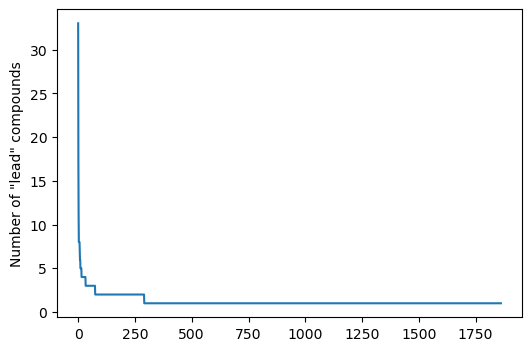

In [8]:
plt.figure(figsize=(6,4))
plt.plot([x.lead_mol_count for x in d]);
plt.ylabel('Number of "lead" compounds');

In [70]:
d[:5]

[(124208, 'CHEMBL5143713', 33, 'Multitarget, Selective Compound Design Yields Potent Inhibitors of a Kinetoplastid Pteridine Reductase 1.'),
 (112049, 'CHEMBL4364284', 17, 'Design, Synthesis, and Efficacy Testing of Nitroethylene- and 7-Nitrobenzoxadiazol-Based Flavodoxin Inhibitors against Helicobacter pylori Drug-Resistant Clinical Strains and in Helicobacter pylori-Infected Mice.'),
 (116417, 'CHEMBL4619772', 11, 'Discovery and Structural Optimization of 4-(Aminomethyl)benzamides as Potent Entry Inhibitors of Ebola and Marburg Virus Infections.'),
 (104951, 'CHEMBL4024746', 8, 'Nonpyrogenic Molecular Adjuvants Based on norAbu-Muramyldipeptide and norAbu-Glucosaminyl Muramyldipeptide: Synthesis, Molecular Mechanisms of Action, and Biological Activities in Vitro and in Vivo.'),
 (137761, 'CHEMBL6153114', 8, 'Property-Based Design of Xanthine Derivatives as Potent and Orally Available TRPC4/5 Inhibitors for Depression and Anxiety.')]

In [18]:
%sql \
    select * from lead_opt.doc_compound_adme_assay_count \
        where doc_chembl_id='CHEMBL5143713' limit 20;

doc_id,molregno,compound_chembl_id,doc_chembl_id,assay_count
124208,30951,CHEMBL26006,CHEMBL5143713,5
124208,694749,CHEMBL1232399,CHEMBL5143713,5
124208,695052,CHEMBL1232702,CHEMBL5143713,5
124208,1439395,CHEMBL2178599,CHEMBL5143713,5
124208,1439396,CHEMBL2178600,CHEMBL5143713,5
124208,1439398,CHEMBL2178602,CHEMBL5143713,5
124208,1439401,CHEMBL2178604,CHEMBL5143713,5
124208,2742199,CHEMBL5170968,CHEMBL5143713,5
124208,2742840,CHEMBL5171609,CHEMBL5143713,5
124208,2744963,CHEMBL5173732,CHEMBL5143713,5


In [72]:
d[-5:]

[(101221, 'CHEMBL3856276', 1, 'Design, Synthesis, and Biological Evaluation of Novel Tetrahydroprotoberberine Derivatives (THPBs) as Selective α1A-Adrenoceptor Antagonists.'),
 (101268, 'CHEMBL3860043', 1, 'Non-Acidic Free Fatty Acid Receptor 4 Agonists with Antidiabetic Activity.'),
 (101271, 'CHEMBL3860046', 1, 'Increasing metabolic stability via the deuterium kinetic isotope effect: An example from a proline-amide-urea aminothiazole series of phosphatidylinositol-3 kinase alpha inhibitors.'),
 (101284, 'CHEMBL3860059', 1, "Design, Synthesis, and Biological Evaluation of First-in-Class Dual Acting Histone Deacetylases (HDACs) and Phosphodiesterase 5 (PDE5) Inhibitors for the Treatment of Alzheimer's Disease."),
 (101434, 'CHEMBL3862029', 1, 'Discovery of 8-Membered Ring Sulfonamides as Inhibitors of Oncogenic Mutant Isocitrate Dehydrogenase 1.')]

How many of those documents contain at least 30 non-reference compounds?

In [14]:
%sql drop table if exists lead_opt.lead_optimization_docs;

%sql \
    select lod.*, compounds_per_doc.mol_count into lead_opt.lead_optimization_docs \
        from lead_opt.lead_opt_docs lod \
        join docs using (doc_id) \
        join lead_opt.compounds_per_doc using (doc_id) \
where doc_type='PUBLICATION' and doi is not null\
    and mol_count>30;
    
d = %sql \
    select * from lead_opt.lead_optimization_docs \
        order by mol_count desc;
print(f'{len(d)} docs found')
d[:5]

770 docs found


[(112401, 'CHEMBL4373715', 1, 'Discovery and Biological Evaluations of Halogenated 2,4-Diphenyl Indeno[1,2-<i>b</i>]pyridinol Derivatives as Potent Topoisomerase IIα-Targeted Chemotherapeutic Agents for Breast Cancer.', 172),
 (119964, 'CHEMBL4765483', 2, '3,4-Dihydropyrimidin-2(1H)-ones as Antagonists of the Human A Adenosine Receptor: Optimization, Structure-Activity Relationship Studies, and Enantiospecific Recognition.', 167),
 (110611, 'CHEMBL4311995', 1, 'Discovery and development of extreme selective inhibitors of the ITD and D835Y mutant FLT3 kinases.', 128),
 (104326, 'CHEMBL4007421', 1, 'Discovery and Preclinical Characterization of 3-((4-(4-Chlorophenyl)-7-fluoroquinoline-3-yl)sulfonyl)benzonitrile, a Novel Non-acetylenic Metabotropic Glutamate Receptor 5 (mGluR5) Negative Allosteric Modulator for Psychiatric Indications.', 125),
 (127075, 'CHEMBL5344428', 4, 'Discovery, Crystallographic Studies, and Mechanistic Investigations of Novel Phenylalanine Derivatives Bearing a Qui

That's a good starting point: we have 770 documents to work with.

Let's save them:

In [15]:
df = d.DataFrame()
import pickle
with open('./results/lead_optimization_docs.pkl','wb') as f:
    pickle.dump(df,f)
df.to_csv('./results/lead_optimization_docs.csv',index=False)

Now let's get the associated compounds:

In [5]:
d = %sql \
    select doc_id, doc_chembl_id,molregno,el.chembl_id compound_chembl_id, compound_type, assay_count, canonical_smiles from \
    (select * from \
        (select doc_id,lod.doc_chembl_id,molregno,'local' compound_type, dcac.assay_count assay_count \
        from lead_opt.lead_optimization_docs lod \
        join lead_opt.filtered_activities using (doc_id) \
        join lead_opt.doc_compound_assay_count dcac using (doc_id,molregno) \
        order by doc_id,molregno)  \
    UNION \
        (select doc_id,doc_chembl_id,molregno,'reference' compound_type, assay_count \
            from (select doc_id,doc_chembl_id,molregno,count(distinct assay_id) assay_count from \
                (select * from lead_opt.lead_optimization_docs lod \
                 join (select activities.doc_id,molregno from activities \
                 except select doc_id,molregno from lead_opt.filtered_activities)\
                 using (doc_id)) t1 \
                join activities using (doc_id,molregno) group by (doc_id,doc_chembl_id,molregno)) \
            order by doc_id,molregno) \
    )\
    join chembl_id_lookup el on (entity_id=molregno and entity_type='COMPOUND') \
    join compound_structures using (molregno) \
    order by doc_id,assay_count desc,molregno;

list(d)[:10]

[(37919, 'CHEMBL1140586', 416886, 'CHEMBL250403', 'local', 34, 'CCCN1CCO[C@H](c2cccc(O)c2)C1'),
 (37919, 'CHEMBL1140586', 3854, 'CHEMBL53', 'reference', 3, 'CN1CCc2cccc3c2[C@H]1Cc1ccc(O)c(O)c1-3'),
 (37919, 'CHEMBL1140586', 19316, 'CHEMBL589', 'reference', 3, 'CCCN(CCC)CCc1cccc2c1CC(=O)N2'),
 (37919, 'CHEMBL1140586', 88815, 'CHEMBL301265', 'reference', 3, 'CCCN[C@H]1CCc2nc(N)sc2C1'),
 (37919, 'CHEMBL1140586', 259724, 'CHEMBL155731', 'local', 3, 'CCCN1CCC[C@@H]2Cc3nc(N)ncc3C[C@H]21'),
 (37919, 'CHEMBL1140586', 416809, 'CHEMBL250002', 'local', 3, 'CCCN1CCO[C@H](c2ccc(F)c(O)c2)C1'),
 (37919, 'CHEMBL1140586', 416811, 'CHEMBL250003', 'local', 3, 'CCCN1CCO[C@H](c2cc(O)cc(O)c2)C1'),
 (37919, 'CHEMBL1140586', 170003, 'CHEMBL101480', 'local', 2, 'CCCN1CCOC(c2cccc(OC)c2)C1'),
 (37919, 'CHEMBL1140586', 170033, 'CHEMBL105646', 'local', 2, 'CCCN1CCOC(c2cccc(Cl)c2)C1'),
 (37919, 'CHEMBL1140586', 170396, 'CHEMBL102463', 'local', 2, 'CCCN1CCOC(c2cccc(O)c2)C1')]

Spot check a few of those values to make sure we didn't miss anything:

In [6]:
%sql \
    select molregno,count(distinct assay_id) from activities where doc_id=37919 and molregno in (3854, 219334, 416886) group by molregno;

molregno,count
3854,3
219334,1
416886,34


In [7]:
df = d.DataFrame()
print(df.shape)
import pickle
with open('./results/lead_optimization_sets.pkl', 'wb') as f:
    pickle.dump(df, f)
df.to_csv('./results/lead_optimization_sets.csv', index=False)

(37295, 7)


Look at number of compounds per doc in our sets:

In [10]:
counts = df.groupby(['doc_id']).agg({'molregno':['count','nunique']}).sort_values(by=('molregno','count'),ascending=False)
counts.head()

molregno        
          count nunique
doc_id                 
112401      176     176
119964      173     173
110611      138     138
104326      127     127
127075      124     124

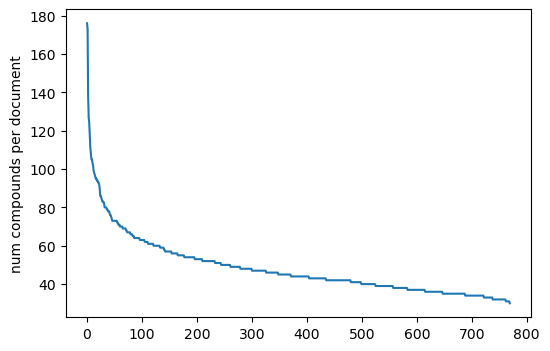

In [11]:
plt.figure(figsize=(6,4))
plt.plot(counts[('molregno','count')].to_list());
plt.ylabel('num compounds per document');

In [12]:
counts.tail()

molregno        
          count nunique
doc_id                 
137618       31      31
128112       31      31
50627        31      31
137140       31      31
113074       30      30

I think that's enough for now. Let's review.
- We have information about 770 ChEMBL "lead optimization" documents (see below for the definition). These are all publications (not patents for the moment) with DOIs.
- For each document we have the title and the number of "lead compounds" (see below for the definition).
- The documents have between 30 and 176 unique compounds each, resulting in just over 37K non-unique compounds (non-unique because the same compound can appear in multiple documents).
- Each document compound is labelled "reference" if it appears in at least 10 other documents or "local" if it appears in a smaller number of other docs.
- Each document compound is labelled with the number of different assays it has values for in that document.

A "lead compound" in a document is defined as:
- Present in less than 10 other documents (Note: this excludes compounds from older documents that then show up in a bunch of new docs. We can potentially solve this in a future update, but it's not as easy as it seems)
- measured in at least two binding assays
- measured in at least two ADME assays
- measured in at least two tox assays

A "lead optimization" document is defined to be a document with:
- At least 10 different assays.
- At least one "lead compound"